# Function 5

<b> Description of the Sample Application:</b> You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. 
Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods



## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |


## Progress Log

| Week | Query Point (x1, x2, x3, x4) | Output (y) | Best y so far | β (kappa) | Search region | Notes |
|---|---|---|---|---|---|---|
|  |  |  |  |  |  |  |
| **Week 1** | 0.037439-0.014236-0.070689-0.986304 | 154.182426 | 1088.860 (unchanged) | 2.5 | full [0, 1)^4 | Deliberately exploratory corner query (high β, sparse 4D coverage). GP had predicted ≈3464.8 in log-space back-transform; true yield was far lower — a sign the RBF surrogate was overconfident extrapolating into an unseen corner. |
| **Week 2** | *(computed below — see Portal Submission section)* | *pending* | 1088.860 (until confirmed) | 1.8 | narrowed box: ±0.25 around current best | Lower β to shift toward exploitation; multi-start L-BFGS-B used to optimise the acquisition function precisely inside the narrowed box, replacing Week 1's pure random-candidate search. |


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")

from plotting_utils import plot_convergence, plot_parallel_coordinates

# Load and Analyse the Data

In [19]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)


# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.037439, 0.014236, 0.070689, 0.986304]   , dtype=np.float64)    # from input.txt
Y_w1_new_point = np.array([154.18242633803845]                       , dtype=np.float64)    # from output.txt

# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point))
Y_updated      = np.append(Y0, Y_w1_new_point)

#print(X_updated)
#print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

In [23]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"Y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: X = {X[best_idx]}, Y = {Y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df)


Input  Shape: (21, 4)
Inputs:
 [[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.037439   0.014236   0.070

# Data Exploration

In [26]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4            Y
count  21.000000  21.000000  21.000000  21.000000    21.000000
mean    0.440247   0.475494   0.458551   0.518128   151.410473
std     0.239916   0.286869   0.256440   0.319212   245.576802
min     0.037439   0.014236   0.070689   0.072880     0.112940
25%     0.224189   0.193610   0.264243   0.190518    24.423088
50%     0.438933   0.534192   0.422598   0.473113    64.420147
75%     0.677491   0.729382   0.656000   0.814870   154.182426
max     0.836478   0.862540   0.879484   0.986304  1088.859618


In [28]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
Y      0
dtype: int64


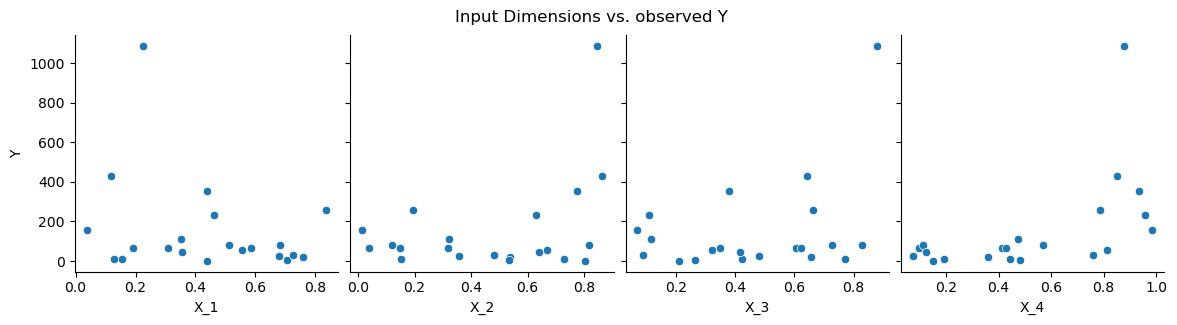

In [30]:
# Pairwise Scatter Plot, showing relationship of y for each input
sns.pairplot(df, y_vars = ['Y'], x_vars = ['X_1', 'X_2', 'X_3', 'X_4'], height = 3)
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.show()

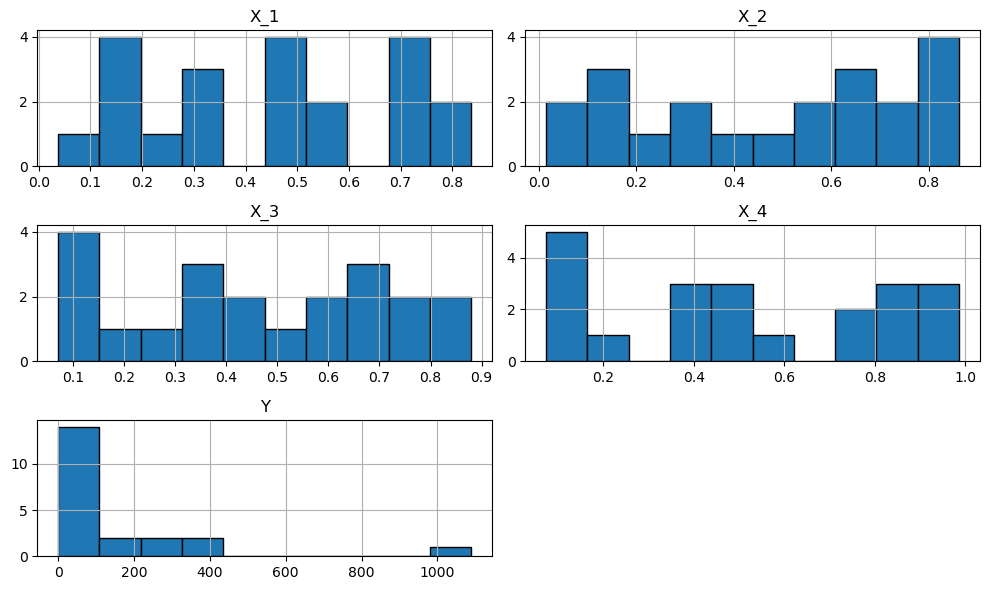

In [32]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [36]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4"]
print("Correlation of each input with Y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with Y:

 corr(X_1, Y) = -0.26346688545320923
 corr(X_2, Y) = 0.36099991629290734
 corr(X_3, Y) = 0.34364449610341097
 corr(X_4, Y) = 0.5376017626445057


<Axes: >

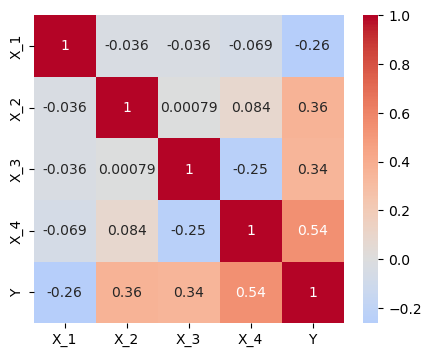

In [38]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

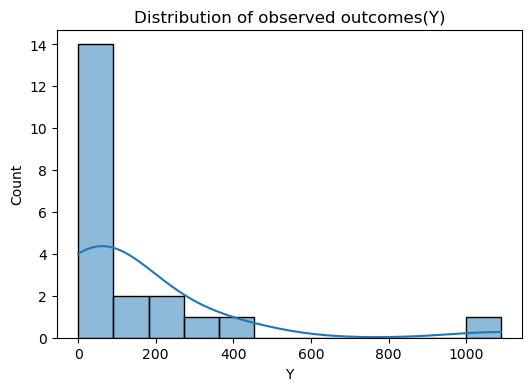

In [40]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process
Keeping the **RBF** kernel for Week 2 as well, as with only 21 points in 4D the isn't yet enough evidence to justify a rougher kernel like Matern 0.5.
As in Week 1, modelling log1p(Y) rather than raw Y, since the output still spans roughly 3 orders of magnitude (0.11 to ~ 1089) and a plain GP would let the largest values dominate the length-scale/variance fit.ce fit.

In [52]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [1.0] * 4, length_scale_bounds = (1e-2, 1e2)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [57]:
# y is spread beyond 1000, If we model with raw values of y, couple of large values dominate the Gaussian Processes' length-scale/variance fit
# Hence, modelling  log1p(y) rather than raw y. Working in log-space keeps the regression well-conditioned

X_scaler       = StandardScaler()
X_s            = X_scaler.fit_transform(X)

Y_log          = np.log1p(Y)
Y_mean, Y_std  = Y_log.mean(), Y_log.std()
Y_s            = (Y_log - Y_mean) / Y_std

# Train the model

gpr.fit(X_s, Y_s)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  2.13**2 * RBF(length_scale=[6.08, 1.37, 3.27, 1.54]) + WhiteKernel(noise_level=1e-05)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [64]:
# Function to predict mean and std for raw x
def predict_yield(X_raw):
    Xs          = X_scaler.transform(X_raw)
    mu_s, std_s = gpr.predict(Xs, return_std = True)
    mu_log      = mu_s * Y_std + Y_mean
    std_log     = std_s * Y_std
    mu_yield    = np.expm1(mu_log)
    return mu_yield, std_log

# Setting a higher beta(= 2.5) for Week -1
#beta         = 2.5                

# Setting a higher beta(= 1.8) for Week -8
beta         = 1.8  

# Function to calculare UCB 
def ucb_log_space(X_raw, beta = beta):
    Xs          = X_scaler.transform(X_raw)
    mu_s, std_s = gpr.predict(Xs, return_std = True)
    return mu_s + beta * std_s

# Commented Code for Week 1 
# n_candidates = 200000
# RNG          = np.random.default_rng(42)
# candidates   = RNG.uniform(0, 1, size = (n_candidates, 4))

# ucb_scores   = ucb_log_space(candidates)
# next_idx     = np.argmax(ucb_scores)
# x_next       = candidates[next_idx]

# pred_mu, pred_std_log = predict_yield(x_next.reshape(1, -1))

# print(f"Suggested next Query Point: {x_next}")
# print(f"Predicted Mean(μ): {pred_mu[0]:.6e}")
# print(f"Predicted Std (σ): {pred_std_log[0]:.6e}")
# print(f"UCB Score: {ucb_scores[next_idx]:.6e}")


# Week 2: Consolidated Bayesian Optimisation Function
Define a consolidated function that includes acquisition optimisation into a single reusable function. Two changes from Week 1's approach:

- **Multi-start L-BFGS-B** on the negative UCB, instead of scoring 200,000 random candidates and taking the arg-max. This locates the acquisition optimum more precisely, as the search area becomes smaller.
- The function accepts explicit **bounds**, so it can be reused for the narrowed region this week and for the full `[0,1)^4` cube in earlier/future weeks alike.

In [67]:
def suggest_next_query(gpr, X_scaler, Y_mean, Y_std, bounds, beta = 1.8, n_restarts = 25, seed = 42):
    rng      = np.random.default_rng(seed)
    dim      = bounds.shape[0]

    def neg_acq(x):
        x           = x.reshape(1, -1)
        Xs          = X_scaler.transform(x)
        mu_s, std_s = gpr.predict(Xs, return_std = True)
        return -(mu_s[0] + beta * std_s[0])

    best_val, best_x = np.inf, None
    starts           = rng.uniform(bounds[:, 0], bounds[:, 1], size = (n_restarts, dim))
    for x0 in starts:
        res          = minimize(neg_acq, x0, bounds = list(zip(bounds[:, 0], bounds[:, 1])), method = "L-BFGS-B")
        if res.fun < best_val:
            best_val, best_x = res.fun, res.x

    mu_next, std_next = predict_yield(best_x.reshape(1, -1))
    return best_x, mu_next[0], std_next[0], -best_val


# Narrow the search region and run the Week 2 query


In [72]:
# Restricting the candidate search to a box of half-width **0.25** around the current best point.
delta      = 0.25
best_x_now = X[best_idx]

lb         = np.clip(best_x_now - delta, 0.0, 0.999999)
ub         = np.clip(best_x_now + delta, 0.0, 0.999999)
bounds     = np.vstack([lb, ub]).T
print("Narrowed search bounds (per dimension):\n", bounds)

x_next, pred_mu, pred_std_log, ucb_next = suggest_next_query(gpr, X_scaler, Y_mean, Y_std, bounds, beta = beta)

print(f"\nSuggested next Query Point: {np.round(x_next, 6)}")
print(f"Predicted Mean (μ)          : {pred_mu:.4f}")
print(f"Predicted Std (σ, log-space): {pred_std_log:.4f}")
print(f"UCB Score                   : {ucb_next:.4f}")

Narrowed search bounds (per dimension):
 [[0.         0.47418902]
 [0.59648049 0.999999  ]
 [0.62948418 0.999999  ]
 [0.62851568 0.999999  ]]

Suggested next Query Point: [0.       0.59648  0.999999 0.999999]
Predicted Mean (μ)          : 2188.6258
Predicted Std (σ, log-space): 1.6249
UCB Score                   : 4.1966


# Perform Visualisation ( Week 1 )

Full 4D UCB surface can't be drawn directly. Hence, we visualise 2D slices for every pair of dimensions, fix the other two dimensions at the current
best-known x, and sweep a grid over the chosen pair. This shows how UCB (and mu, sigma) behave locally around the best point found so far.

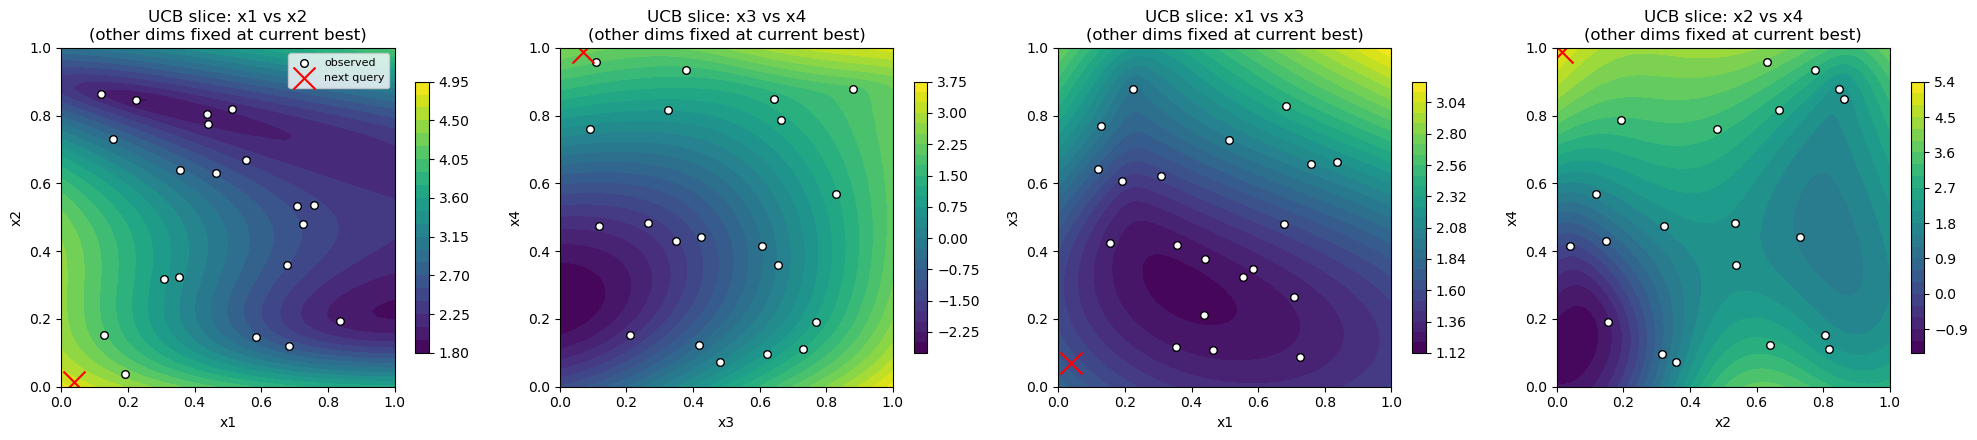

In [112]:
grid_n = 60
grid_1d = np.linspace(0, 1, grid_n)
pairs = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point = X[best_idx].copy()  # anchor the other two dims here
 
fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    A, B = np.meshgrid(grid_1d, grid_1d)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()
 
    scores = ucb_log_space(grid_points).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels=25, cmap="viridis")
    ax.scatter(X[:, d1], X[:, d2], c="white", edgecolor="black", s=30, label="observed")
    ax.scatter(x_next[d1], x_next[d2], c="red", marker="x", s=250, label="next query")
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice: x{d1+1} vs x{d2+1}\n(other dims fixed at current best)")
    fig.colorbar(im, ax=ax, shrink=0.8)
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()

# Week 2: UCB Vusualisation ( Zoomed to the narrowed region )
This week zoomed into the narrowed box rather than the full unit cube, so the local structure around the current best is visible in more detail.l.

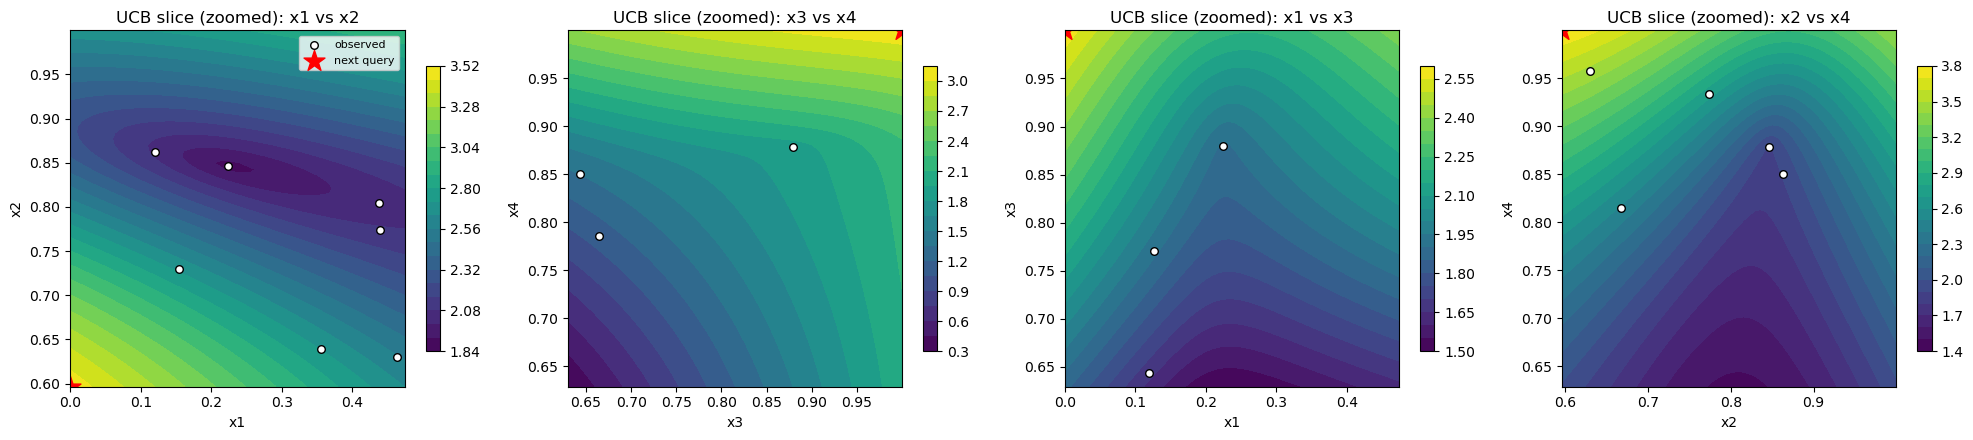

In [81]:
grid_n          = 60
pairs           = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point     = best_x_now.copy()

fig, axes       = plt.subplots(1, len(pairs), figsize = (5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    g1          = np.linspace(bounds[d1, 0], bounds[d1, 1], grid_n)
    g2          = np.linspace(bounds[d2, 0], bounds[d2, 1], grid_n)
    A, B        = np.meshgrid(g1, g2)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()

    scores = ucb_log_space(grid_points, beta).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels = 25, cmap = "viridis")
    ax.scatter(X[:, d1], X[:, d2], c = "white", edgecolor = "black", s = 30, label = "observed")
    ax.scatter(x_next[d1], x_next[d2], c = "red", marker = "*", s = 250, label = "next query")
    ax.set_xlim(bounds[d1, 0], bounds[d1, 1])
    ax.set_ylim(bounds[d2, 0], bounds[d2, 1])
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice (zoomed): x{d1+1} vs x{d2+1}")
    fig.colorbar(im, ax = ax, shrink = 0.8)
axes[0].legend(loc="upper right", fontsize = 8)
plt.tight_layout()
plt.show()


# Portal Submission 

In [75]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(x_next)
print(f"Points to be submitted(Week 1):\n{submission_str}")

Points to be submitted(Week 1):
0.000000-0.596480-0.999999-0.999999
